# **Tanya Kavuru (G35018292)**

# Compas Analysis (Python Translation)

This notebook reproduces the analytical workflow from the original R script in **pure Python**.  
It covers:

1. Data loading
2. Data cleaning and preprocessing
3. Exploratory data analysis (EDA)
4. Logistic regression model development
5. Model evaluation and diagnostics
6. Race-level error rate comparison

The goal is to mirror the R workflow as closely as possible while using standard Python libraries such as `pandas`, `numpy`, `matplotlib`, and `statsmodels`.

In [19]:
# Core libraries for data wrangling, modeling, and plotting
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 200)

## Loading the Data

We use the same COMPAS dataset referenced in the original workflow. The selected fields cover:
- demographics
- charge severity
- prior offenses
- COMPAS score information
- recidivism outcomes

In [20]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print("Number of rows in raw_data:", raw_data.shape[0])
display(raw_data.head(10))

Number of rows in raw_data: 7214


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.0,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.0,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.0,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.0,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.0,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.0,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less

However, not all rows are usable for analysis. We apply the same filters described in the R script:

- Keep rows where `days_b_screening_arrest` is between -30 and 30
- Remove rows where `is_recid == -1`
- Remove ordinary traffic offenses where `c_charge_degree == "O"`
- Remove rows where `score_text == "N/A"`

We also convert date fields and construct factor-style variables to match the R workflow.

In [21]:
# Variables grouped by type so the preprocessing logic is easy to follow
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
        "priors_count", "days_b_screening_arrest", "decile_score", "is_recid",
        "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

exclude_cols = set(numeric_vars + datetime_vars)
for col in df.columns:
    if col not in exclude_cols:
        df[col] = df[col].astype("category")

df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = pd.Categorical(df["age_cat"], categories=["25 - 45", "Greater than 45", "Less than 25"])
df["race_factor"] = pd.Categorical(df["race"])
df["gender_factor"] = pd.Categorical(df["sex"].replace({"Female": "Female", "Male": "Male"}), categories=["Male", "Female"])

df["score_binary"] = (df["score_text"].astype(str) != "Low").astype(int)
df["score_factor"] = pd.Categorical(df["score_binary"].map({0: "LowScore", 1: "HighScore"}))

print("Number of rows after filtering:", df.shape[0])
display(df.head())
print("\nDataFrame info:")
print(df.info())

Number of rows after filtering: 6172


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_binary,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,0,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,0,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,0,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,0,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,1,HighScore



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in         

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [22]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.total_seconds() / (24 * 60 * 60)

corr_value = df["length_of_stay"].corr(df["decile_score"])
print("Correlation between length_of_stay and decile_score:", round(corr_value, 4))

Correlation between length_of_stay and decile_score: 0.2074


## Demographic Breakdown After Filtering

In [23]:
print("Age category summary:")
display(df["age_cat"].value_counts(dropna=False).rename_axis("age_cat").reset_index(name="count"))

print("\nRace summary:")
display(df["race"].value_counts(dropna=False).rename_axis("race").reset_index(name="count"))

Age category summary:


,age_cat,count
0,25 - 45,3532
1,Less than 25,1347
2,Greater than 45,1293



Race summary:


,race,count
0,African-American,3175
1,Caucasian,2103
2,Hispanic,509
3,Other,343
4,Asian,31
5,Native American,11


In [24]:
race_percent = (df["race"].value_counts(normalize=True) * 100).round(2)
for race_name, pct in race_percent.items():
    print(f"{race_name}: {pct:.2f}%")

African-American: 51.44%
Caucasian: 34.07%
Hispanic: 8.25%
Other: 5.56%
Asian: 0.50%
Native American: 0.18%


In [25]:
print("Score text summary:")
display(df["score_text"].value_counts(dropna=False).rename_axis("score_text").reset_index(name="count"))

Score text summary:


,score_text,count
0,Low,3421
1,Medium,1607
2,High,1144


In [26]:
sex_race_crosstab = pd.crosstab(df["sex"], df["race"])
print("Cross-tab: sex by race")
display(sex_race_crosstab)

Cross-tab: sex by race


race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [27]:
print("Sex summary:")
display(df["sex"].value_counts(dropna=False).rename_axis("sex").reset_index(name="count"))

sex_percent = (df["sex"].value_counts(normalize=True) * 100).round(2)
for sex_name, pct in sex_percent.items():
    print(f"{sex_name}: {pct:.2f}%")

Sex summary:


,sex,count
0,Male,4997
1,Female,1175


Male: 80.96%
Female: 19.04%


In [28]:
recid_count = (df["two_year_recid"] == 1).sum()
recid_pct = recid_count / len(df) * 100

print("Number of people with two_year_recid == 1:", recid_count)
print(f"Percent with two_year_recid == 1: {recid_pct:.2f}%")

Number of people with two_year_recid == 1: 2809
Percent with two_year_recid == 1: 45.51%


Judges are often presented with both categorical risk labels and decile scores.  
To mirror the original visual comparison, we plot the decile score distributions for Black and White defendants side by side.

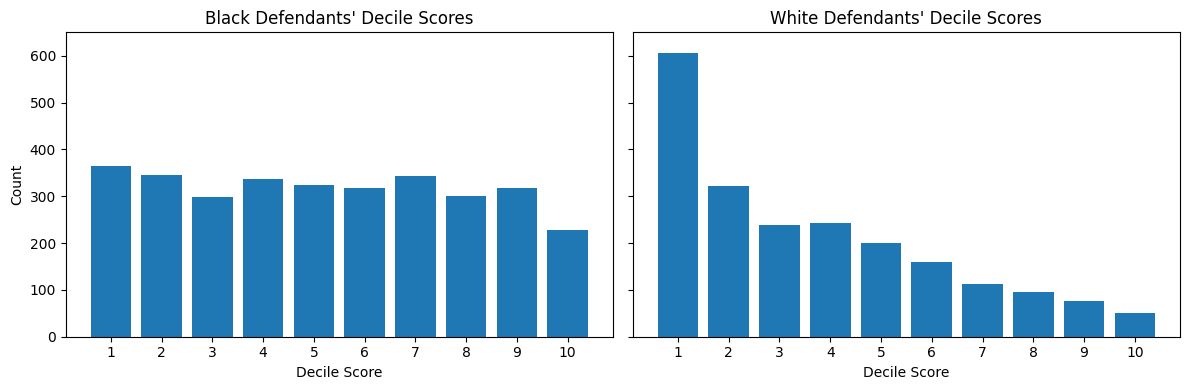

In [29]:
black_scores = (
    df.loc[df["race"] == "African-American", "decile_score"]
      .value_counts()
      .sort_index()
      .reindex(range(1, 11), fill_value=0)
)

white_scores = (
    df.loc[df["race"] == "Caucasian", "decile_score"]
      .value_counts()
      .sort_index()
      .reindex(range(1, 11), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].bar(black_scores.index.astype(str), black_scores.values)
axes[0].set_title("Black Defendants' Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

axes[1].bar(white_scores.index.astype(str), white_scores.values)
axes[1].set_title("White Defendants' Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [30]:
decile_race_crosstab = pd.crosstab(df["decile_score"], df["race"])
print("Cross-tab: decile_score by race")
display(decile_race_crosstab)

Cross-tab: decile_score by race


race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in COMPAS

After filtering, the next step is to estimate whether race is associated with receiving a higher COMPAS score after controlling for:
- sex
- age category
- number of prior offenses
- charge severity
- future recidivism

This matches the logistic regression stage from the original R script.

In [31]:
formula = '''
score_binary ~
C(gender_factor, Treatment(reference="Male")) +
C(age_factor, Treatment(reference="25 - 45")) +
C(race_factor, Treatment(reference="Caucasian")) +
priors_count +
C(crime_factor) +
two_year_recid
'''

model_glm = smf.logit(formula=formula, data=df).fit(disp=False)

print(model_glm.summary())

                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        19:05:48   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                               -1.5255      0.079    

The original analysis interprets selected coefficients in terms of how much more likely a person is to receive a higher score, holding the other variables constant.

To mirror that logic, we convert key logistic coefficients into adjusted effects using the same style of calculation shown in the R notebook.

In [32]:
intercept = model_glm.params["Intercept"]
control = np.exp(intercept) / (1 + np.exp(intercept))

def adjusted_effect(beta):
    odds_ratio = np.exp(beta)
    return odds_ratio / (1 - control + (control * odds_ratio))

key_terms = [
    'C(race_factor, Treatment(reference="Caucasian"))[T.African-American]',
    'C(gender_factor, Treatment(reference="Male"))[T.Female]',
    'C(age_factor, Treatment(reference="25 - 45"))[T.Less than 25]'
]

for term in key_terms:
    if term in model_glm.params.index:
        beta = model_glm.params[term]
        print(term)
        print("  coefficient      =", round(beta, 5))
        print("  exp(coefficient) =", round(np.exp(beta), 5))
        print("  adjusted effect  =", round(adjusted_effect(beta), 5))
        print()

C(race_factor, Treatment(reference="Caucasian"))[T.African-American]
  coefficient      = 0.47721
  exp(coefficient) = 1.61157
  adjusted effect  = 1.45284

C(gender_factor, Treatment(reference="Male"))[T.Female]
  coefficient      = 0.22127
  exp(coefficient) = 1.24766
  adjusted effect  = 1.19479

C(age_factor, Treatment(reference="25 - 45"))[T.Less than 25]
  coefficient      = 1.30839
  exp(coefficient) = 3.70021
  adjusted effect  = 2.49612



## Model Evaluation and Diagnostics

Next, we generate predicted probabilities and predicted classes, then evaluate the model using:
- confusion matrix
- accuracy
- precision
- recall
- false positive rate (FPR)
- false negative rate (FNR)

This mirrors the evaluation section in the R notebook.

In [33]:
df["pred_prob"] = model_glm.predict(df)
df["pred_label"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")
df["pred_class"] = pd.Categorical(df["pred_label"], categories=["No Recid", "Recid"])

display(df[["pred_prob", "pred_class", "two_year_recid"]].head())

,pred_prob,pred_class,two_year_recid
0,0.023951,No Recid,0
1,0.410362,No Recid,1
2,0.883057,Recid,1
5,0.065185,No Recid,0
6,0.949096,Recid,1


In [34]:
print("── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    index=df["pred_class"],
    columns=df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"],
    dropna=False
)

display(overall_cm)

TP = overall_cm.loc["Recid", 1] if ("Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
TN = overall_cm.loc["No Recid", 0] if ("No Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FP = overall_cm.loc["Recid", 0] if ("Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FN = overall_cm.loc["No Recid", 1] if ("No Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
n = TP + TN + FP + FN

accuracy = (TP + TN) / n if n else np.nan
precision = TP / (TP + FP) if (TP + FP) else np.nan
recall = TP / (TP + FN) if (TP + FN) else np.nan
fpr = FP / (FP + TN) if (FP + TN) else np.nan
fnr = FN / (FN + TP) if (FN + TP) else np.nan

print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")

── Overall Confusion Matrix ──────────────────────────────────────────


Actual,0,1
Predicted,,
No Recid,2653,945
Recid,710,1864


Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [35]:
print("── Confusion Matrix by Race ──────────────────────────────────────────")

temp = df.copy()
temp["actual"] = temp["two_year_recid"].astype(int)
temp["pred"] = (temp["pred_class"].astype(str) == "Recid").astype(int)

rows = []
for race_name, group in temp.groupby("race", observed=False):
    tp = ((group["pred"] == 1) & (group["actual"] == 1)).sum()
    tn = ((group["pred"] == 0) & (group["actual"] == 0)).sum()
    fp = ((group["pred"] == 1) & (group["actual"] == 0)).sum()
    fn = ((group["pred"] == 0) & (group["actual"] == 1)).sum()
    n_group = len(group)

    rows.append({
        "race": race_name,
        "n": n_group,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": round((tp + tn) / n_group, 3) if n_group else np.nan,
        "Precision": round(tp / (tp + fp), 3) if (tp + fp) else np.nan,
        "Recall": round(tp / (tp + fn), 3) if (tp + fn) else np.nan,
        "FPR": round(fp / (fp + tn), 3) if (fp + tn) else np.nan,
        "FNR": round(fn / (fn + tp), 3) if (fn + tp) else np.nan
    })

race_metrics = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
display(race_metrics)

── Confusion Matrix by Race ──────────────────────────────────────────


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
0,African-American,3175,1373,959,555,288,0.734,0.712,0.827,0.367,0.173
1,Caucasian,2103,381,1148,133,441,0.727,0.741,0.464,0.104,0.536
2,Hispanic,509,81,306,14,108,0.760,0.853,0.429,0.044,0.571
3,Other,343,22,216,3,102,0.694,0.880,0.177,0.014,0.823
4,Asian,31,2,22,1,6,0.774,0.667,0.250,0.043,0.750
5,Native American,11,5,2,4,0,0.636,0.556,1.000,0.667,0.000


In [36]:
print("── FPR and FNR Disparity by Race ─────────────────────────────────────")

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

caucasian_row = disparity.loc[disparity["race"] == "Caucasian"]
if not caucasian_row.empty:
    caucasian_fpr = caucasian_row["FPR"].iloc[0]
    caucasian_fnr = caucasian_row["FNR"].iloc[0]

    disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
    disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

display(disparity)

── FPR and FNR Disparity by Race ─────────────────────────────────────


,race,n,FPR,FNR,delta_FPR,delta_FNR
0,African-American,3175,0.367,0.173,0.263,-0.363
1,Caucasian,2103,0.104,0.536,0.000,0.000
2,Hispanic,509,0.044,0.571,-0.060,0.035
3,Other,343,0.014,0.823,-0.090,0.287
4,Asian,31,0.043,0.750,-0.061,0.214
5,Native American,11,0.667,0.000,0.563,-0.536


## Interpretation Notes

- Small numeric differences from the R notebook can happen because of differences in library defaults and optimization routines.
- The workflow is still conceptually aligned with the original script:
  - same dataset
  - same filtering logic
  - same main explanatory variables
  - same logistic regression structure
  - same confusion-matrix-based diagnostics
  - same race-level comparison of error rates

This version is fully implemented in Python and is organized so another analyst can follow the workflow from data loading through evaluation.